# Static and movie trajectories in the static PCA basis

Fit three principal components to the stimulus-averaged static NatRaster, then project the matched movie NatRaster into exactly the same basis. Static time 0 s is color-aligned to movie time 2.5 s, so the extra movie interval from 2.0 to 2.5 s appears in the earlier part of the colormap.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np
from sklearn.decomposition import PCA
import yaml

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils import load_natraster, match_static_dynamic_rasters
from useful_stuff.general_utils import TimeSeries

In [7]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27"#  "red_20260726to27" # 
    dynamic_exp_name: str = "baby1_260716to24" #  "red_20260720to24" #
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    source_fs: int = 1000
    plot_fs: int = 100
    movie_window_s: tuple[float, float] = (2.0, 3.5)
    movie_pca_start_s: float = 0.15
    static_alignment_s: float = 2.5
    cmap: str = "viridis"


cfg = Cfg()
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
movie_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
cfg, static_path, movie_path

(Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, source_fs=1000, plot_fs=100, movie_window_s=(2.0, 3.5), movie_pca_start_s=0.15, static_alignment_s=2.5, cmap='viridis'),
 PosixPath('/Users/tizianocausin/sd_local/data/baby1_260718to27_natraster_img.mat'),
 PosixPath('/Users/tizianocausin/sd_local/data/baby1_260716to24_natraster_vid.mat'))

## Load, match, and average stimuli

Matching retains the standard `img_` response for every movie identity and puts the two conditions in the same stimulus order. The stimulus average leaves one channel vector per timepoint. When `use_reliable_channels=True`, both sessions use the reliable channels selected from the static session. Set `reliable_channels_config` or `reliable_channels_key` to override the default YAML path or static-session dataset key.

In [8]:
# By default, apply the static-session reliability list to both sessions.
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / "reliable_channels.yaml"
    )
    reliable_channels_key = (
        cfg.reliable_channels_key or cfg.static_exp_name
    )
# end if cfg.use_reliable_channels

# Apply the identical physical-channel selection to both sessions.
static_rasters, static_names, static_channel_numbers = load_natraster(
    static_path,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
movie_rasters, movie_names, movie_channel_numbers = load_natraster(
    movie_path,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(static_channel_numbers, movie_channel_numbers):
    raise ValueError(
        "Static and movie sessions retained different physical channels."
    )
# end if retained channels differ
channel_numbers = static_channel_numbers

static_rasters, movie_rasters, shared_stimuli = match_static_dynamic_rasters(
    static_rasters, static_names, movie_rasters, movie_names,
)

# Use the established resampling utility on channels x time x stimuli arrays.
static_ts = TimeSeries(static_rasters, cfg.source_fs)
movie_ts = TimeSeries(movie_rasters, cfg.source_fs)
static_ts.resample(cfg.plot_fs)
movie_ts.resample(cfg.plot_fs)

# PCA samples are timepoints and PCA features are neural channels.
static_signal = static_ts.get_array().mean(axis=2).T
movie_signal = movie_ts.get_array().mean(axis=2).T
static_times_s = np.arange(static_signal.shape[0]) / cfg.plot_fs
movie_times_s = np.arange(movie_signal.shape[0]) / cfg.plot_fs
movie_mask = (movie_times_s >= cfg.movie_window_s[0]) & (movie_times_s < cfg.movie_window_s[1])
movie_pca_mask = movie_times_s >= cfg.movie_pca_start_s

print(f"Reliable-channel filter: {cfg.use_reliable_channels}")
if cfg.use_reliable_channels:
    print(f"Reliability config: {reliable_channels_config}")
    print(f"Reliability key: {reliable_channels_key}")
# end if cfg.use_reliable_channels
print(f"Matched stimuli: {len(shared_stimuli)}")
print(f"Selected MATLAB channels: {channel_numbers.tolist()}")
print(f"Selected channel count: {len(channel_numbers)}")
print(f"Static signal: {static_signal.shape} (time, channels)")
print(f"Movie window: {movie_mask.sum()} timepoints")
print(f"Movie PCA fit: {movie_pca_mask.sum()} timepoints ({cfg.movie_pca_start_s:.2f} s to end)")

Reliable-channel filter: True
Reliability config: /Users/tizianocausin/Desktop/static_dynamic/reliable_channels.yaml
Reliability key: baby1_260718to27
Matched stimuli: 100
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Selected channel count: 30
Static signal: (100, 30) (time, channels)
Movie window: 150 timepoints
Movie PCA fit: 335 timepoints (0.15 s to end)


## Fit on static and project movie

`PCA.transform` applies both the static-derived channel centering and the static-derived component directions to the movie signal.

In [9]:
static_pca = PCA(n_components=3)
static_scores = static_pca.fit_transform(static_signal)
movie_scores = static_pca.transform(movie_signal[movie_mask])
movie_window_times_s = movie_times_s[movie_mask]

print("Explained variance: " + ", ".join(
    f"PC{index}: {ratio:.1%}"
    for index, ratio in enumerate(static_pca.explained_variance_ratio_, start=1)
))
print(f"Cumulative variance explained by PC1–PC3: {static_pca.explained_variance_ratio_.sum():.1%}")

Explained variance: PC1: 98.2%, PC2: 0.8%, PC3: 0.2%
Cumulative variance explained by PC1–PC3: 99.1%


## 3D trajectories

The static color coordinates are shifted by 2.5 s. Consequently, static time 0 s and movie time 2.5 s receive exactly the same color.

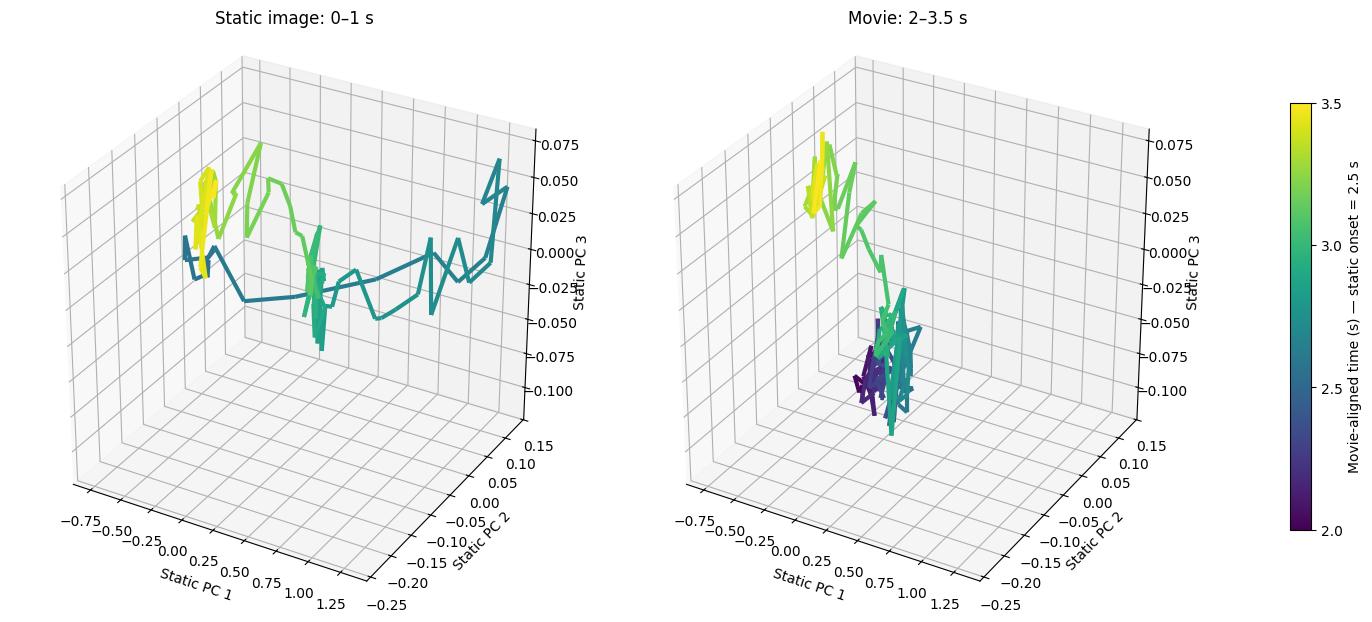

In [10]:
static_color_times_s = static_times_s + cfg.static_alignment_s
color_norm = Normalize(*cfg.movie_window_s)

figure = plt.figure(figsize=(14, 6), constrained_layout=True)
axes = [
    figure.add_subplot(1, 2, 1, projection="3d"),
    figure.add_subplot(1, 2, 2, projection="3d"),
]

for axis, scores, color_times_s, title in (
        (axes[0], static_scores, static_color_times_s, "Static image: 0–1 s"),
        (axes[1], movie_scores, movie_window_times_s, "Movie: 2–3.5 s"),
        ):
    # Give every adjacent pair of 3D points the color of its midpoint time.
    segments = np.stack([scores[:-1], scores[1:]], axis=1)
    segment_times_s = (color_times_s[:-1] + color_times_s[1:]) / 2
    trajectory = Line3DCollection(
        segments, cmap=cfg.cmap, norm=color_norm, linewidth=3,
    )
    trajectory.set_array(segment_times_s)
    axis.add_collection3d(trajectory)
    axis.set(
        xlabel="Static PC 1", ylabel="Static PC 2",
        zlabel="Static PC 3", title=title,
    )
    axis.set_box_aspect((1, 1, 1))
# end for axis, scores

# Identical limits make the two trajectories directly comparable in the shared basis.
all_scores = np.vstack([static_scores, movie_scores])
for dimension, setter in enumerate(("set_xlim", "set_ylim", "set_zlim")):
    lower, upper = all_scores[:, dimension].min(), all_scores[:, dimension].max()
    margin = 0.05 * (upper - lower)
    for axis in axes:
        getattr(axis, setter)(lower - margin, upper + margin)
    # end for axis
# end for dimension, setter

colorbar = figure.colorbar(trajectory, ax=axes, shrink=0.75, pad=0.08)
colorbar.set_label("Movie-aligned time (s) — static onset = 2.5 s")
colorbar.set_ticks([2.0, 2.5, 3.0, 3.5])
plt.show()

## PC1–PC2 overlay

Both conditions are drawn on the same two-dimensional axes. Point colors retain the movie-aligned time scale used above; line style distinguishes the trajectories where they overlap.

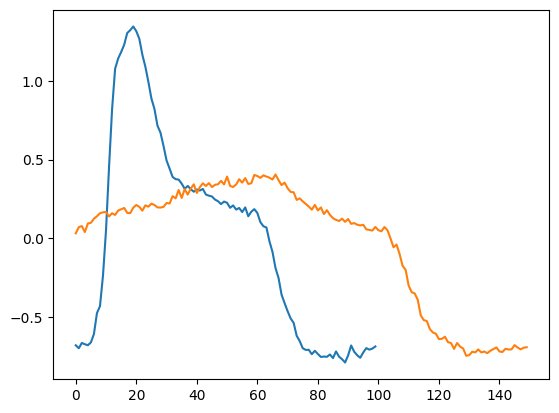

In [6]:
plt.plot(static_scores[:,0])
plt.plot(movie_scores[:,0])

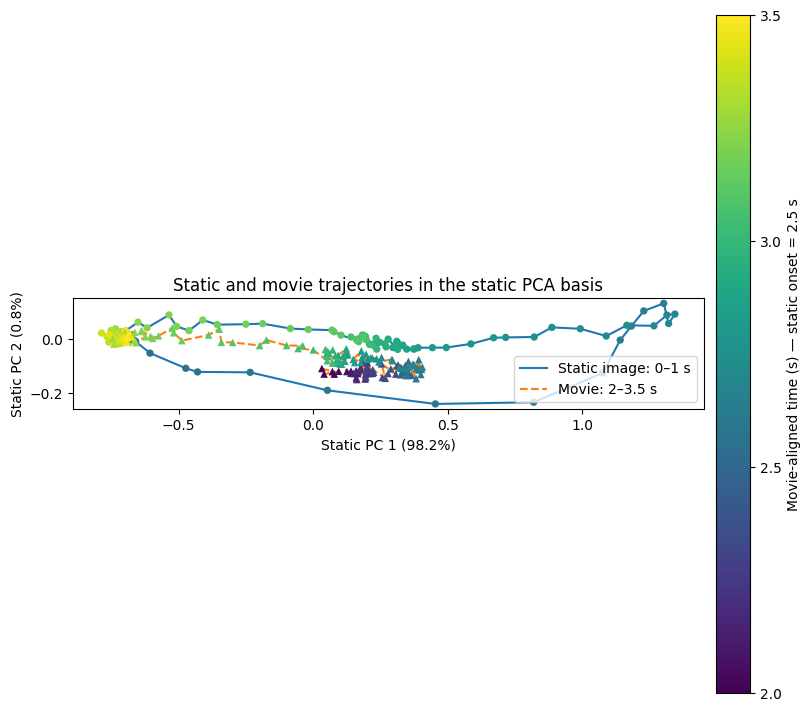

In [11]:
figure, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)

axis.plot(
    static_scores[:, 0], static_scores[:, 1],
    color="tab:blue", linewidth=1.5, label="Static image: 0–1 s", zorder=1,
)
axis.plot(
    movie_scores[:, 0], movie_scores[:, 1],
    color="tab:orange", linewidth=1.5, linestyle="--",
    label="Movie: 2–3.5 s", zorder=1,
)
axis.scatter(
    static_scores[:, 0], static_scores[:, 1],
    c=static_color_times_s, cmap=cfg.cmap, norm=color_norm,
    marker="o", s=28, edgecolor="none", zorder=2,
)
points = axis.scatter(
    movie_scores[:, 0], movie_scores[:, 1],
    c=movie_window_times_s, cmap=cfg.cmap, norm=color_norm,
    marker="^", s=30, edgecolor="none", zorder=2,
)

axis.set(
    xlabel=f"Static PC 1 ({static_pca.explained_variance_ratio_[0]:.1%})",
    ylabel=f"Static PC 2 ({static_pca.explained_variance_ratio_[1]:.1%})",
    title="Static and movie trajectories in the static PCA basis",
)
axis.set_aspect("equal", adjustable="box")
axis.legend()
colorbar = figure.colorbar(points, ax=axis, pad=0.02)
colorbar.set_label("Movie-aligned time (s) — static onset = 2.5 s")
colorbar.set_ticks([2.0, 2.5, 3.0, 3.5])
plt.show()

# Static and movie trajectories in the movie PCA basis

Fit three principal components to the stimulus-averaged movie response from 150 ms through the final sample. Then project the complete static trajectory and the displayed 2–3.5 s movie trajectory using the movie-derived channel centering and component directions.

In [12]:
# Fit the movie basis on every movie-response sample from 150 ms onward.
movie_pca = PCA(n_components=3)
movie_pca.fit(movie_signal[movie_pca_mask])

# Apply the movie-derived centering and axes to both displayed trajectories.
static_in_movie_scores = movie_pca.transform(static_signal)
movie_in_movie_scores = movie_pca.transform(movie_signal[movie_mask])

print("Movie-basis explained variance: " + ", ".join(
    f"PC{index}: {ratio:.1%}"
    for index, ratio in enumerate(movie_pca.explained_variance_ratio_, start=1)
))
print(
    "Cumulative variance explained by movie PC1–PC3: "
    f"{movie_pca.explained_variance_ratio_.sum():.1%}"
)

Movie-basis explained variance: PC1: 91.4%, PC2: 2.8%, PC3: 0.5%
Cumulative variance explained by movie PC1–PC3: 94.7%


## 3D trajectories in the movie basis

The time alignment, colormap, and displayed intervals are identical to the static-basis plot above; only the PCA basis changes.

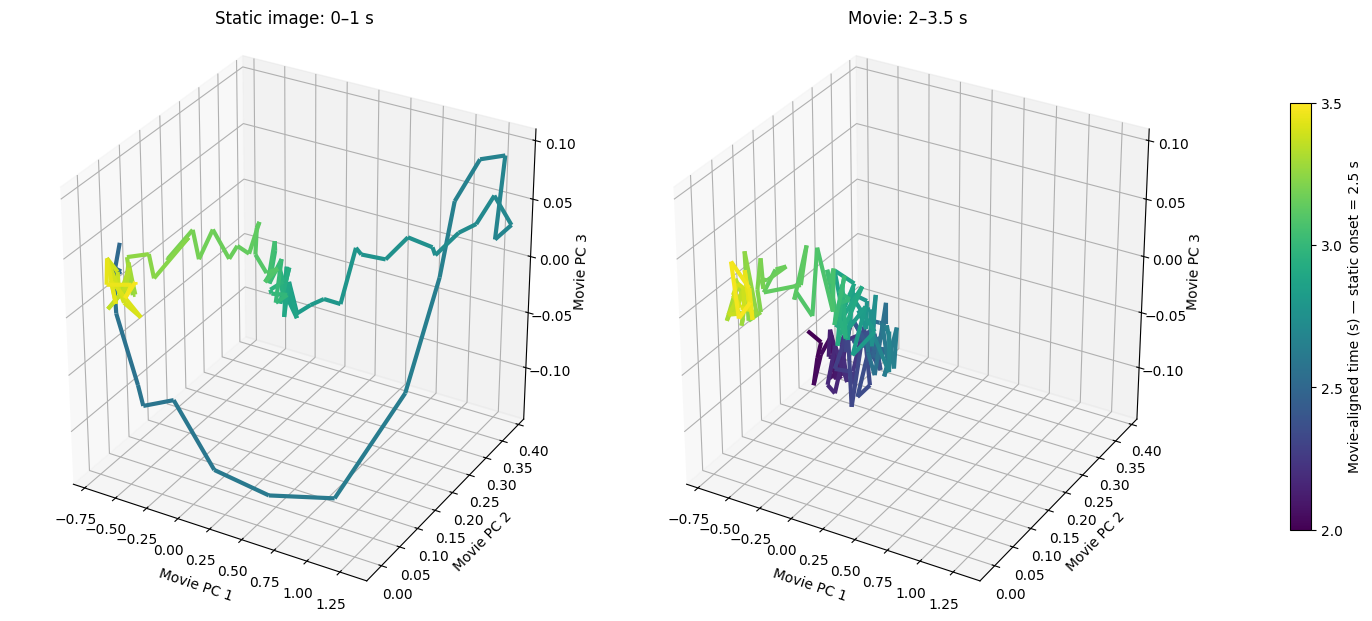

In [13]:
figure = plt.figure(figsize=(14, 6), constrained_layout=True)
axes = [
    figure.add_subplot(1, 2, 1, projection="3d"),
    figure.add_subplot(1, 2, 2, projection="3d"),
]

for axis, scores, color_times_s, title in (
        (axes[0], static_in_movie_scores, static_color_times_s, "Static image: 0–1 s"),
        (axes[1], movie_in_movie_scores, movie_window_times_s, "Movie: 2–3.5 s"),
        ):
    # Give every adjacent pair of 3D points the color of its midpoint time.
    segments = np.stack([scores[:-1], scores[1:]], axis=1)
    segment_times_s = (color_times_s[:-1] + color_times_s[1:]) / 2
    trajectory = Line3DCollection(
        segments, cmap=cfg.cmap, norm=color_norm, linewidth=3,
    )
    trajectory.set_array(segment_times_s)
    axis.add_collection3d(trajectory)
    axis.set(
        xlabel="Movie PC 1", ylabel="Movie PC 2",
        zlabel="Movie PC 3", title=title,
    )
    axis.set_box_aspect((1, 1, 1))
# end for axis, scores

# Identical limits make the two trajectories directly comparable in the shared basis.
all_movie_basis_scores = np.vstack([static_in_movie_scores, movie_in_movie_scores])
for dimension, setter in enumerate(("set_xlim", "set_ylim", "set_zlim")):
    lower = all_movie_basis_scores[:, dimension].min()
    upper = all_movie_basis_scores[:, dimension].max()
    margin = 0.05 * (upper - lower)
    for axis in axes:
        getattr(axis, setter)(lower - margin, upper + margin)
    # end for axis
# end for dimension, setter

colorbar = figure.colorbar(trajectory, ax=axes, shrink=0.75, pad=0.08)
colorbar.set_label("Movie-aligned time (s) — static onset = 2.5 s")
colorbar.set_ticks([2.0, 2.5, 3.0, 3.5])
plt.show()

## PC1–PC2 overlay in the movie basis

As above, line style identifies condition and point color gives movie-aligned time.

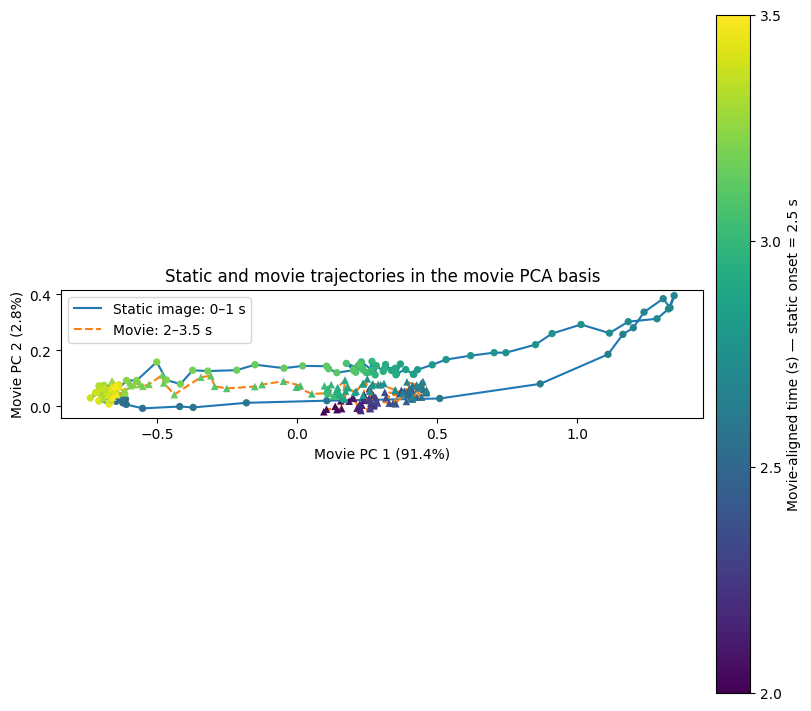

In [14]:
figure, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)

axis.plot(
    static_in_movie_scores[:, 0], static_in_movie_scores[:, 1],
    color="tab:blue", linewidth=1.5, label="Static image: 0–1 s", zorder=1,
)
axis.plot(
    movie_in_movie_scores[:, 0], movie_in_movie_scores[:, 1],
    color="tab:orange", linewidth=1.5, linestyle="--",
    label="Movie: 2–3.5 s", zorder=1,
)
axis.scatter(
    static_in_movie_scores[:, 0], static_in_movie_scores[:, 1],
    c=static_color_times_s, cmap=cfg.cmap, norm=color_norm,
    marker="o", s=28, edgecolor="none", zorder=2,
)
points = axis.scatter(
    movie_in_movie_scores[:, 0], movie_in_movie_scores[:, 1],
    c=movie_window_times_s, cmap=cfg.cmap, norm=color_norm,
    marker="^", s=30, edgecolor="none", zorder=2,
)

axis.set(
    xlabel=f"Movie PC 1 ({movie_pca.explained_variance_ratio_[0]:.1%})",
    ylabel=f"Movie PC 2 ({movie_pca.explained_variance_ratio_[1]:.1%})",
    title="Static and movie trajectories in the movie PCA basis",
)
axis.set_aspect("equal", adjustable="box")
axis.legend()
colorbar = figure.colorbar(points, ax=axis, pad=0.02)
colorbar.set_label("Movie-aligned time (s) — static onset = 2.5 s")
colorbar.set_ticks([2.0, 2.5, 3.0, 3.5])
plt.show()

# Correlation between the static and movie PCA bases

Each cell is the signed Pearson correlation across channels between one static loading vector and one movie loading vector. PCA component signs are arbitrary, so correlation magnitude measures alignment while the sign only records the orientation selected by each fit. The full matrix allows components with different rank orders to be compared.

Static-PC rows × movie-PC columns (signed Pearson r):
[[ 0.979 -0.852 -0.208]
 [-0.718  0.657  0.549]
 [-0.39   0.546 -0.638]]


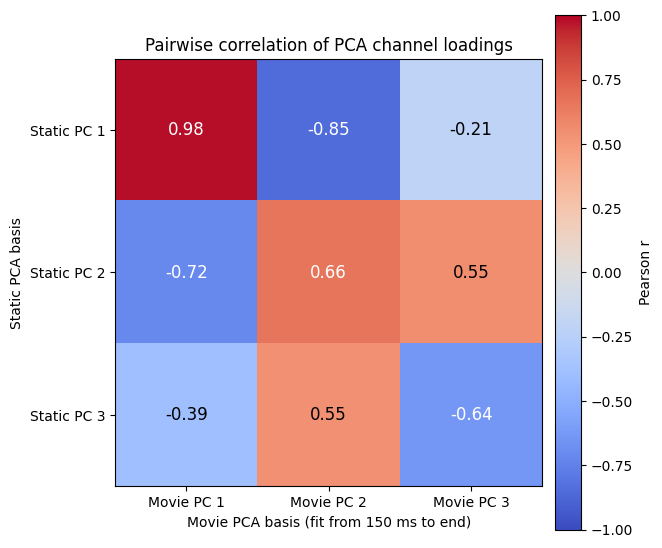

In [11]:
# Stack the two sets of three channel-loading vectors and retain the cross-block.
all_components = np.vstack([static_pca.components_, movie_pca.components_])
basis_correlation = np.corrcoef(all_components)[:3, 3:]

print("Static-PC rows × movie-PC columns (signed Pearson r):")
print(np.array2string(basis_correlation, precision=3, suppress_small=True))

figure, axis = plt.subplots(figsize=(6.5, 5.5), constrained_layout=True)
image = axis.imshow(basis_correlation, cmap="coolwarm", vmin=-1, vmax=1)

for static_index in range(3):
    for movie_index in range(3):
        correlation = basis_correlation[static_index, movie_index]
        text_color = "white" if abs(correlation) >= 0.55 else "black"
        axis.text(
            movie_index, static_index, f"{correlation:.2f}",
            ha="center", va="center", color=text_color, fontsize=12,
        )
    # end for movie_index
# end for static_index

axis.set(
    xticks=np.arange(3), yticks=np.arange(3),
    xticklabels=[f"Movie PC {index}" for index in range(1, 4)],
    yticklabels=[f"Static PC {index}" for index in range(1, 4)],
    xlabel="Movie PCA basis (fit from 150 ms to end)",
    ylabel="Static PCA basis",
    title="Pairwise correlation of PCA channel loadings",
)
colorbar = figure.colorbar(image, ax=axis, pad=0.03)
colorbar.set_label("Pearson r")
plt.show()